# Correlation function for the transverse field Ising model using MPS simulations

## Part a

In [2]:
import sys
from pathlib import Path

PROJECT_ROOT = str(Path.cwd().parent.resolve())
if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)

import a_mps_Gio, b_model_Gio, c_tebd_Gio
import numpy as np
from scipy.linalg import svd
import importlib 
import matplotlib.pyplot as plt
#from tqdm import tqdm

In [3]:
importlib.reload(a_mps_Gio)
importlib.reload(b_model_Gio)
importlib.reload(c_tebd_Gio)

<module 'c_tebd_Gio' from '/Users/giovanniconcheri/Desktop/ResearchJob/Student-Research-Job/c_tebd_Gio.py'>

In [74]:
sigmay = np.array([[0,-1j],[1j,0]])
sigmax = np.array([[0,1],[1,0]])
sigmaz = np.array([[1., 0.], [0., -1.]])

In [ ]:
def construct_intermediate_tensors(psi, psi1, L):
    tensor1 = [np.array([[1]])]
    tensor1.append(np.tensordot(psi.Bs[L-1], psi1.Bs[L-1].conj(), [[1,2],[1,2]])) # vL [i] [vR] , vL* [i*] [vR*] -> vL vL*
    #indeces of Bs go from 0 to L-1
    #for j in range(10) goes from 0 to 9 
    #for j in range (9,0,-1) goes from 9 to 1
    for j in range(L-2,0,-1):
        tensor2 = np.tensordot(psi.Bs[j],tensor1[-1], [2,0]) # vL i [vR] ,[vL] vL* -> vL i vL*
        tensor1.append(np.tensordot(tensor2, psi1.Bs[j].conj(), [[1,2],[1,2]])) # vL [i] [vL*], vL* [i*] [vR*] ->  vL vL*
    return tensor1


def correlation_allsites(psi, psi1, X, L):

    tensor1 = construct_intermediate_tensors(psi,psi1,L)

    corr_list = []

    tensorA = np.tensordot(psi.Bs[0], psi1.Bs[0].conj(),[[0,1],[0,1]]) # [vL] [i] vR , [vL*] [i*] vR* -> vR vR*
    tensorB = np.tensordot(psi.Bs[0], X, [1,1]) # vL [i] vR , i [i*] -> vL vR i
    tensorC = np.tensordot(tensorB,psi1.Bs[0].conj(), [[0,2],[0,1]]) # [vL] vR [i], [vL*] [i*] vR* -> vR vR*
    corr_list.append(np.tensordot(tensorC,tensor1[L-1], [[0,1],[0,1]])) # [vR] [vR*], [vL] [vL*]

    for j in range(1,L):
        tensorB = np.tensordot(psi.Bs[j], X, [1,1]) # vL [i] vR , i [i*] -> vL vR i
        tensorbeforeC = np.tensordot(tensorA, tensorB, [0,0]) # [vR] vR*, [vL] vR i -> vR* vR i
        tensorC = np.tensordot(tensorbeforeC,psi1.Bs[j].conj(), [[0,2],[0,1]]) # [vR*] vR [i], [vL*] [i*] vR* -> vR vR*
        #print(tensorC.shape)
        #print(tensor1[L-j-2].shape) #- mettili se c'è sum mismatch prima di un certo tensorproduct
        corr_list.append(np.tensordot(tensorC,tensor1[L-j-1], [[0,1],[0,1]])) # [vR] [vR*], [vL] [vL*]
        #tensorintermediate = np.tensordot(psi1.Bs[j], psi.Bs[j].conj(),[1,1]) # vL [i] vR , vL* [i*] vR* -> vL vR vL* vR*
        #tensorloop = np.tensordot(tensorA, tensorintermediate, [[0,1],[0,2]]) # [vR] [vR*], [vL] vR [vL*] vR* -> vR vR*
        tensorintermediate = np.tensordot(tensorA, psi.Bs[j], [0,0]) # [vR] vR*, [vL] i vR -> vR* i vR
        tensorloop = np.tensordot(tensorintermediate, psi1.Bs[j].conj(), [[0,1],[0,1]]) # [vR*] [i] vR, [vL*] [i*] vR* -> vR vR*
        tensorA = tensorloop    

    return corr_list

In [78]:
import pickle
import os

def correlation_Ctj(L, J, g, X, Y, n, dt, k = 0.5, h = 0, chi_max = 200, site = None,
                    save_results = False, savedir = "simulations", ops_name = "sigmay"):
    if g>J: #paramagnetic case
        E0, psi, model = c_tebd_Gio.example_TEBD_gs_finite(L,J,g,h,k)
    else: #ferromagnetic case -> have to find unique gs
        E0, psi, _ = c_tebd_Gio.example_TEBD_gs_finite(L,J,g,h=10**-2.5,k=k)
        model = b_model_Gio.TFIModel(L,J=J,g=g,h=h,k=k)

        #check magnetization
        sigmax = np.array([[0,1],[1,0]])
        x_value = correlation_allsites(psi, psi, sigmax, L)
        print(np.mean(x_value))
        if np.mean(x_value) > 0:
            print("Ground state is the one with positive magnetization")
        else:
            print("Ground state is the one with negative magnetization")

    psi1 = psi.copy() #take a copy of psi which is ground state
    S = []
    if site is None:
        site = L//2 # if no site is specified, take the middle one
    i = site # i= site index of Y
    tensor1 = np.tensordot(psi.Bs[i], Y, [1,1]) # vL [i] vR, i [i*] -> vL vR i
    psi.Bs[i] = tensor1.transpose([0,2,1])
    
    U_bond = c_tebd_Gio.calc_U_bonds_real(model, dt)
    result = []
    N=2**n

    for r in range(N):
        exp_factor = np.exp(1j*E0*r*dt)
        
        if r != 0:
            c_tebd_Gio.run_TEBD(psi, U_bond, N_steps=1, chi_max=chi_max, eps=1.e-10) #found new psi by applying e^-iHdt
        S.append(psi.entanglement_entropy())

        corr_list = correlation_allsites(psi, psi1, X, L)

        result.append(np.array(corr_list) * exp_factor)

    if save_results:
        if g>J:
            phase = "para"
        else:
            phase = "ferro"
        
        subfold = (f"_L{L}" 
            + f"_{ops_name}"
            + f"_n{n}"
            + f"_dt{dt}"
            + f"_g{g}"
            +f"_J{J}"
            +f"_k{k}"
            +f"_h{h}"
            +f"_chi{chi_max}"
            +".pkl")
        
        filename_s = "S.pkl"

        filename_corr = "Corr.pkl"

        fpath_s = os.path.join(savedir, phase, subfold, filename_s)
        fpath_corr = os.path.join(savedir, phase, subfold, filename_corr)

        os.makedirs(os.path.dirname(fpath_s), exist_ok=True)
        os.makedirs(os.path.dirname(fpath_corr), exist_ok=True)

        with open(fpath_s, "wb") as f:
            pickle.dump(S, f)

        with open(fpath_corr, "wb") as f:
            pickle.dump(result, f)

    return S, result

## Simulations

### Ferromagnetic

In [79]:
L = 17; J = 1.; g = 0.1; X = sigmay; Y = sigmay; n = 10; dt = 0.01; k = 0.1; h = 0; chi_max = 200
N = 2**n

In [80]:
S_ferro, Corr_ferro = correlation_Ctj(L = L, J = J, g = g, X = X, Y = Y, n = n, dt = dt, k = k, h = h, chi_max = chi_max, 
                                    # site=0
                                    )

finite TEBD, (imaginary time evolution)
L=17, J=1.0, g=0.10, h = 0.0031622776601683794, k = 0.100
dt = 0.10000: E = -16.1474462053077
dt = 0.01000: E = -16.1535554277073
dt = 0.00100: E = -16.1542099110439
dt = 0.00010: E = -16.1542757468581
dt = 0.00001: E = -16.1542823311827
final bond dimensions:  [2, 4, 8, 16, 19, 20, 21, 21, 21, 21, 20, 19, 16, 8, 4, 2]
0.9941512898237218
Ground state is the one with positive magnetization


In [83]:
import simulation

simulation.correlation_Ctj(L = L, J = J, g = g, X = X, Y = Y, n = n, dt = dt, k = k, h = h, chi_max = chi_max)

finite TEBD, (imaginary time evolution)
L=17, J=1.0, g=0.10, h = 0.0031622776601683794, k = 0.100
dt = 0.10000: E = -16.1474462053077
dt = 0.01000: E = -16.1535554277073
dt = 0.00100: E = -16.1542099110439
dt = 0.00010: E = -16.1542757468581
dt = 0.00001: E = -16.1542823311827
final bond dimensions:  [2, 4, 8, 16, 19, 20, 21, 21, 21, 21, 20, 19, 16, 8, 4, 2]
0.9941512898237218
Ground state is the one with positive magnetization


Use this cell to check whether simulation.py yields same results as the MPS simulations in this notebook for the ferromagnetic phase.

In [ ]:
import pickle

with open("simulation/ferro/L17_sigmay_n10_dt0.01_g0.1_J1.0_k0.1_h0_chi200/Corr.pkl", "rb") as f:
    Corr_ferrooo = pickle.load(f)

with open("simulation/ferro/L17_sigmay_n10_dt0.01_g0.1_J1.0_k0.1_h0_chi200/S.pkl", "rb") as f:
    S_ferrooo = pickle.load(f)

In [4]:
import pickle

with open("simulations/ferro/L55_sigmay_n12_dt0.01_g0.15_J1.0_k0.1_h0_chi200/Corr.pkl", "rb") as f:
    Corr_ferro = pickle.load(f)

with open("simulations/ferro/L55_sigmay_n12_dt0.01_g0.15_J1.0_k0.1_h0_chi200/S.pkl", "rb") as f:
    S_ferro = pickle.load(f)

In [6]:
L=55
n=12
N=2**n
g = 0.15
k = 0.1

Plot of Correlation Function

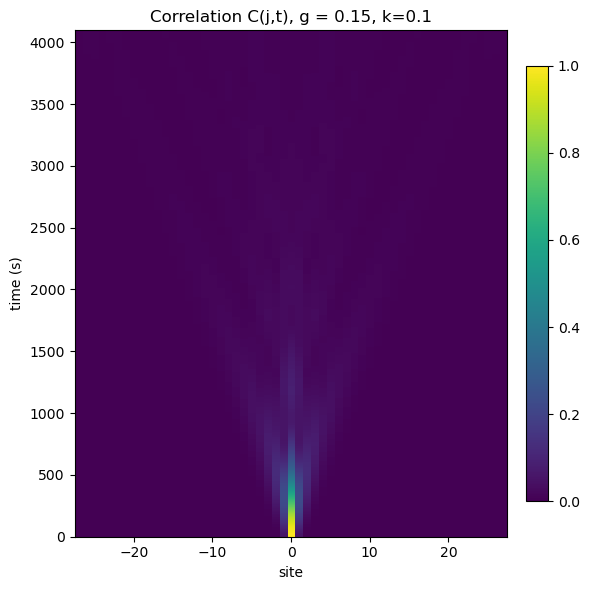

In [7]:
from matplotlib.colors import LogNorm

fig, ax = plt.subplots(figsize = (6,6))
data = np.abs(Corr_ferro)
# im = ax.imshow(data, norm=LogNorm(vmin=data.min(), vmax=data.max()),
#                        aspect='auto', interpolation='none', origin='lower',
#                        extent=[-(L//2)-0.5, L//2+0.5, 0, N])
im = ax.imshow(data, aspect='auto', interpolation='none', origin = 'lower',  extent = [-(L//2)-0.5, L//2+0.5, 0, N])
fig.colorbar(im, fraction=0.046, pad=0.04)  # Add colorbar
ax.set_title(f'Correlation C(j,t), g = {g}, k={k}')
ax.set(xlabel = 'site', ylabel = 'time (s)')
# ax.set(ylim=[0,1200])
# ax.plot(np.linspace(0,L//2+0.5,100), np.linspace(0,850,100))
# ax.plot(np.linspace(0,-L//2+0.5,100), np.linspace(0,850,100))
plt.tight_layout()

### Calculation of slope of corr func for a given threshold

Calculation needed to estimate number of sites need for correlation function to almost hit boundary

-35 35


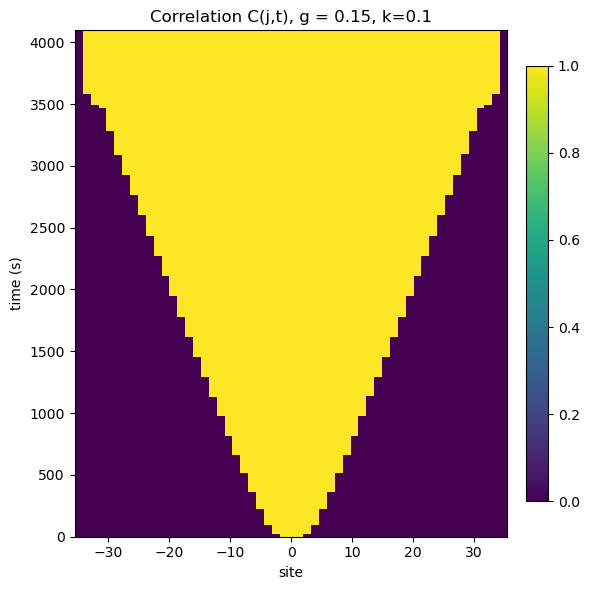

In [28]:
fig, ax = plt.subplots(figsize = (6,6))
thresh = 10**-3
new_corr = np.where(np.abs(Corr_ferro) > thresh, 1, 0)
# im = ax.imshow(np.abs(Corr_ferro), aspect='auto', interpolation='none', origin = 'lower',  extent = [-(L//2)-0.5, L//2+0.5,0,N])
im = ax.imshow(new_corr, aspect='auto', interpolation='none', origin = 'lower',  extent = [-(L//2)-0.5, L//2+0.5, 0, N])
print(-(L//2), L//2)
fig.colorbar(im, fraction=0.046, pad=0.04)  # Add colorbar
ax.set_title(f'Correlation C(j,t), g = {g}, k={k}')
ax.set(xlabel = 'site', ylabel = 'time (s)')
# ax.set(ylim=[0,1200])
# ax.plot(np.linspace(0,L//2+0.5,100), np.linspace(0,850,100))
# ax.plot(np.linspace(0,-L//2+0.5,100), np.linspace(0,850,100))
# plt.savefig(f"temporary_figs/corr_ferro_centralsite_g{g}_k{k}_L{L}_thresh{thresh}.png")
plt.tight_layout()

In [16]:
# for central site:
# corr = new_corr[:,L//2+3:-2]
corr = new_corr[:,L//2+5:-5]
# corr = new_corr[:,L//2:]
# for left site:
# corr = new_corr[:,3:-2]

x = np.arange(0, corr.shape[1], 1)
y = []
for i in range(corr.shape[1]):
    if np.any(corr[:,i]):
        y.append(np.where(corr[:,i])[0][0])
    else:
        y.append(corr.shape[0]) # se non c'è nessun punto in cui corr è 1, metti un valore grande per y

In [17]:
y[-1]-y[-2]

np.int64(166)

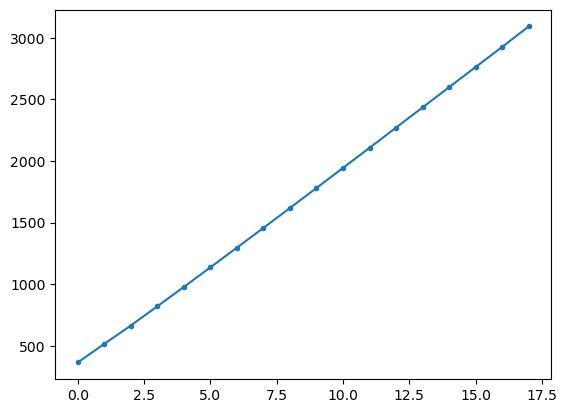

In [18]:
plt.plot(x,y, '.-')
# plt.savefig(f"temporary_figs/edge_centralsite_g{g}_k{k}_L{L}.png")

coefficients:  161.05779153784565 339.6198830431394


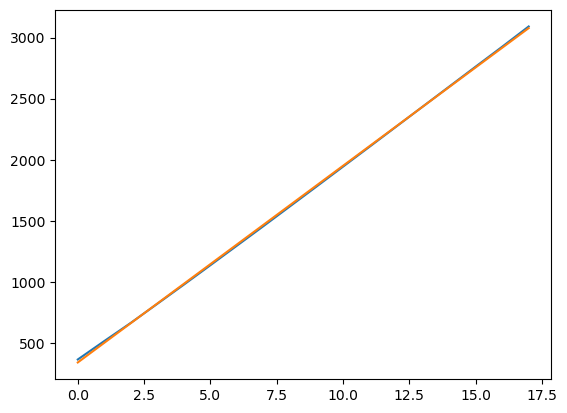

In [19]:
from scipy.optimize import curve_fit

def test(x,a,b):
    return a*x+b

param, param_cov = curve_fit(test, x, y)

ans = test(x,param[0],param[1])

plt.plot(x,y)
plt.plot(x,ans)

print("coefficients: ", param[0], param[1])

### new_corr derived with threshold 10^-2

first coefficient is slope, second is intercept, third is difference between last two points of the curve when not truncated

coefficients for propagation from central site+3:
- g=0.2, k=0.1, (L=17): 155.09999993911313 234.80000021340447 137 (until last right site-1)
- g=0.15, k=0.1, (L=17): 176.89999957846467 256.40000008967735 148 (until last right site-1)
- g=0.1, k=0.1, (L=17): 
- g=0.05, k=0.1, (L=17): 220.60000000612115 260.0999999710188 226 (until last right site-2)

In [27]:
#total sites needed for correlation to almost hit boundary:
((4096-148-256.40000008967735)/176.89999957846467 + 4)*2+1

((4096-166-339.6198830431394)/161.05779153784565 + 9)*2+1


63.58499129628493

In [24]:
# ram needed for L=4096, chi_max = 200, n=10, dt = 0.01, g = 0.1, J = 1, k = 0.1, h = 0:
chi_max = 400
L = 70
L*chi_max**2*2*64/(8*10**9) #in GB

0.1792

### new_corr derived with threshold 10^-3

first coefficient is slope, second is intercept, third is difference between last two points of the curve when not truncated

coefficients for propagation from outmost left site+3:
- g=0.05, k=0.1: coefficients:  225.23030292082802 27.363637112276695
- g=0.08, k=0.1: coefficients:  211.37575748377878 40.30909227823162
- g=0.1, k=0.1: coefficients:  196.860606226799 55.52727173951284
- g=0.15, k=0.1: coefficients:  179.8704414192038 80.6448719139092
- g=0.2, k=0.1: coefficients:  150.04848472470192 61.181818999304696


coefficients for propagation from central site+3 until last right site-1:
- g=0.05, k=0.1: 
- g=0.08, k=0.1:
- g=0.1, k=0.1 (L=17): coefficients: 156.2999999260993,  95.20000022633928, 297
- g=0.1, k=0.1 (L=15): 151.50000000000003 99.49999999999999 
- g=0.15, k=0.1:
- g=0.2, k=0.1: coefficients:  136.59999993360378 74.20000038573465

In [ ]:
#total sites needed for correlation to almost hit boundary:
((4096-297-95.20000022633928)/156.2999999260993 + 4)*2+1

56.39347410780379

In [207]:
from matplotlib.colors import LogNorm

def simulation_ferro(L, J, g, X, Y, n, dt, k = 0, h = 0, chi_max = 200, log=True, ylim=None, ax=None):
    _, Corr_ferro = correlation_Ctj(L = L, J = J, g = g, X = X, Y = Y, n = n, dt = dt, k = k, h = h, chi_max = chi_max)
    # ensure N is defined locally and fig is always available
    N = 2**n
    if ax is None:
        fig, ax = plt.subplots(figsize = (6,6))
        created_fig = True
    else:
        # get the Figure object from the provided Axes
        fig = ax.figure
        created_fig = False

    if log:
        # magnitude, avoid zeros
        data = np.abs(Corr_ferro)
        eps = 1e-15
        data = np.where(data > eps, data, eps)
        im = ax.imshow(data, norm=LogNorm(vmin=data.min(), vmax=data.max()),
                       aspect='auto', interpolation='none', origin='lower',
                       extent=[-(L//2)-0.5, L//2+0.5, 0, N])
    else:
        im = ax.imshow(np.abs(Corr_ferro), aspect='auto', interpolation='none', origin='lower',
                       extent=[-(L//2)-0.5, L//2+0.5, 0, N])

    fig.colorbar(im, fraction=0.046, pad=0.04)  # Add colorbar
    ax.set_title(f'Correlation C(j,t), g = {g}, k = {k}')
    ax.set(xlabel = 'site', ylabel = 'time (s)')
    if ylim is not None:
        ax.set(ylim=ylim)
    plt.tight_layout()
    if created_fig:
        plt.show()
# ...existing code...

finite TEBD, (imaginary time evolution)
L=11, J=1.0, g=0.05, h = 0.0031622776601683794, k = 0.000
dt = 0.10000: E = -10.0428270370252
dt = 0.01000: E = -10.0428614937664
dt = 0.00100: E = -10.0428637885426
dt = 0.00010: E = -10.0428640092799
dt = 0.00001: E = -10.0428640312684
final bond dimensions:  [2, 4, 6, 6, 6, 6, 6, 6, 4, 2]
0.9978751564494599
Ground state is the one with positive magnetization
finite TEBD, (imaginary time evolution)
L=11, J=1.0, g=0.10, h = 0.0031622776601683794, k = 0.000
dt = 0.10000: E = -10.0671703734477
dt = 0.01000: E = -10.0672072633414
dt = 0.00100: E = -10.0672097881570
dt = 0.00010: E = -10.0672100318486
dt = 0.00001: E = -10.0672100561316
final bond dimensions:  [2, 4, 7, 8, 8, 8, 8, 7, 4, 2]
0.9941295787546974
Ground state is the one with positive magnetization
finite TEBD, (imaginary time evolution)
L=11, J=1.0, g=0.20, h = 0.0031622776601683794, k = 0.000
dt = 0.10000: E = -10.1647786843919
dt = 0.01000: E = -10.1648505581009
dt = 0.00100: E = -10.

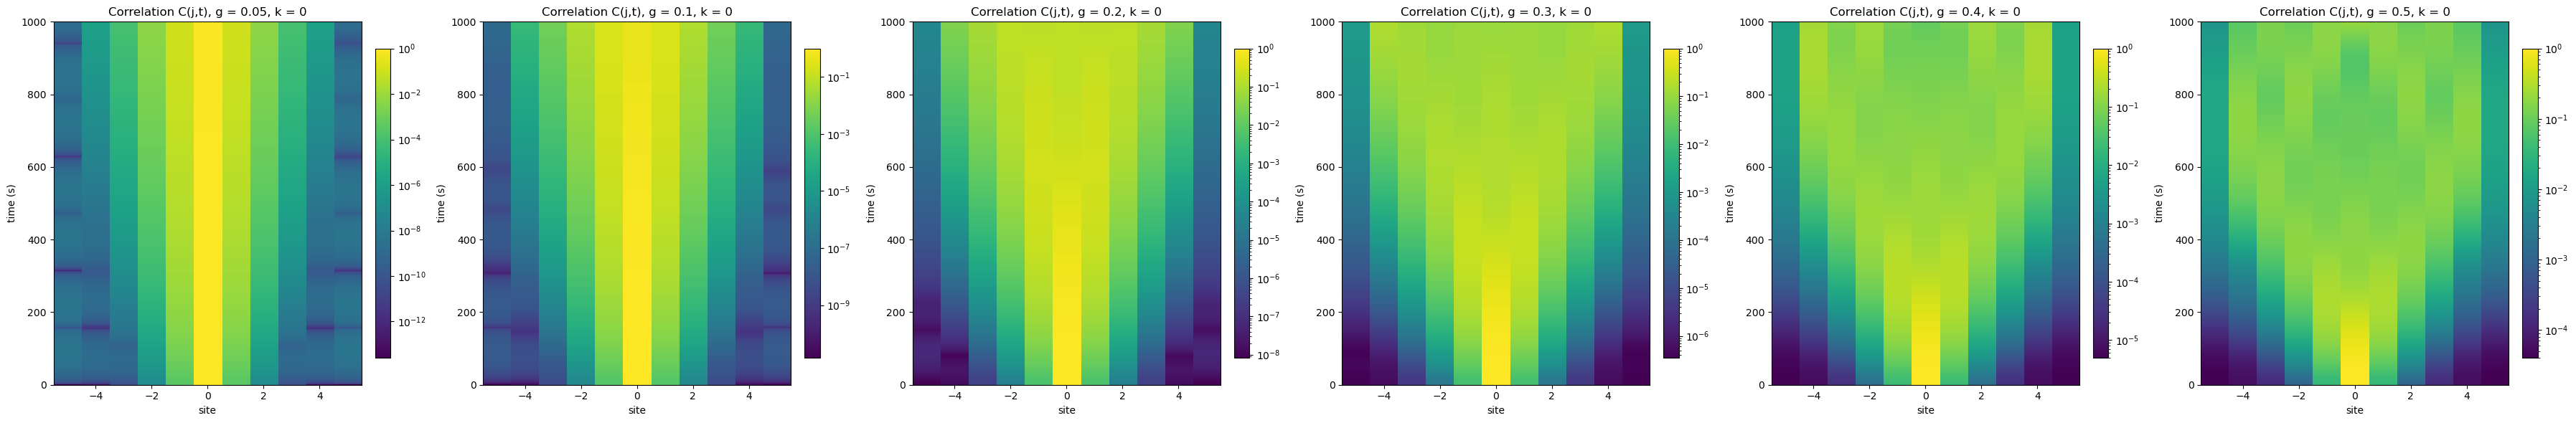

finite TEBD, (imaginary time evolution)
L=11, J=1.0, g=0.05, h = 0.0031622776601683794, k = 0.050
dt = 0.10000: E = -10.0499983102151
dt = 0.01000: E = -10.0508923725416
dt = 0.00100: E = -10.0509858258081
dt = 0.00010: E = -10.0509952114651
dt = 0.00001: E = -10.0509961500158
final bond dimensions:  [2, 4, 8, 14, 16, 16, 14, 8, 4, 2]
0.9964353983059259
Ground state is the one with positive magnetization
finite TEBD, (imaginary time evolution)
L=11, J=1.0, g=0.10, h = 0.0031622776601683794, k = 0.050
dt = 0.10000: E = -10.0762603770784
dt = 0.01000: E = -10.0772241206154
dt = 0.00100: E = -10.0773246007420
dt = 0.00010: E = -10.0773346907362
dt = 0.00001: E = -10.0773356997176
final bond dimensions:  [2, 4, 8, 14, 17, 17, 14, 8, 4, 2]
0.992065635946065
Ground state is the one with positive magnetization
finite TEBD, (imaginary time evolution)
L=11, J=1.0, g=0.20, h = 0.0031622776601683794, k = 0.050
dt = 0.10000: E = -10.1816136051711
dt = 0.01000: E = -10.1828836114648
dt = 0.00100: E

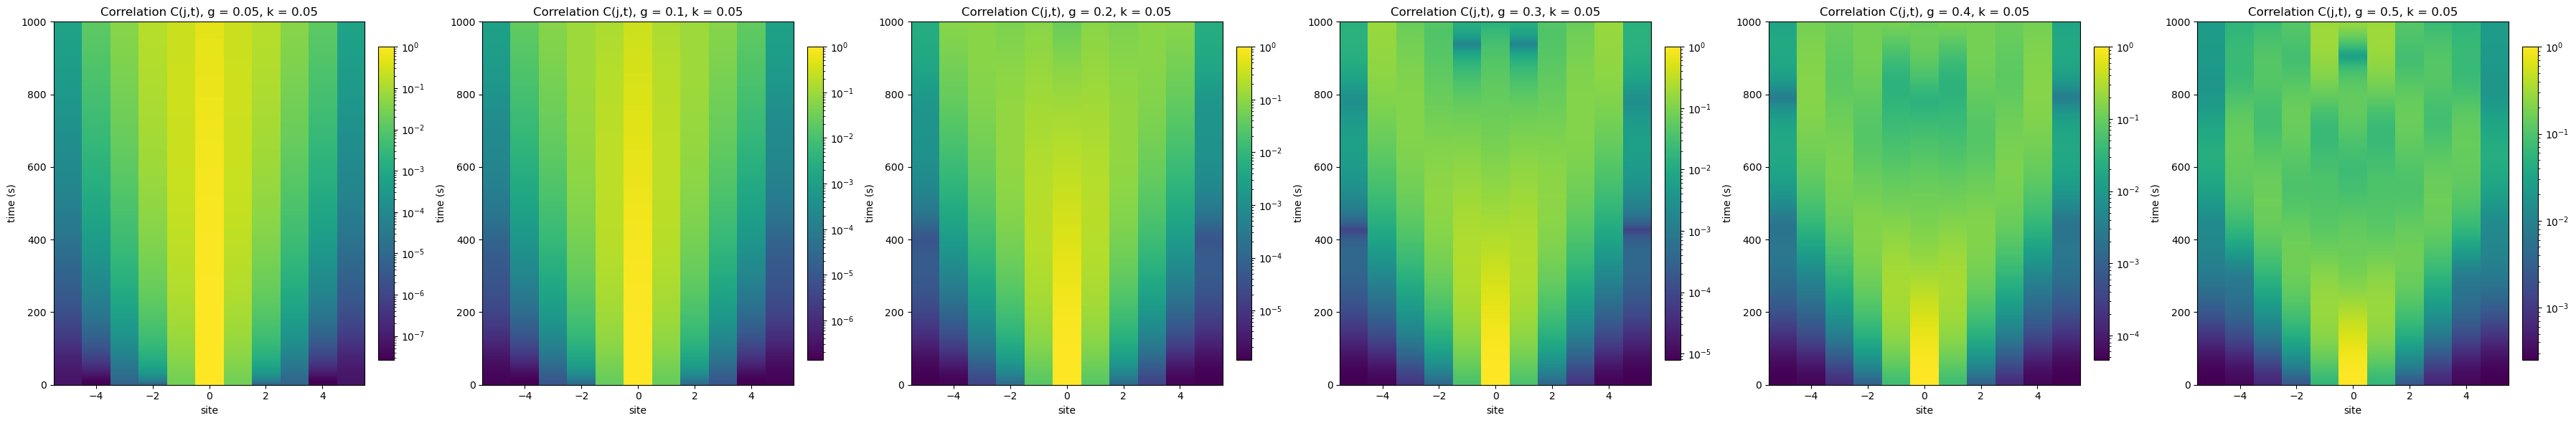

finite TEBD, (imaginary time evolution)
L=11, J=1.0, g=0.05, h = 0.0031622776601683794, k = 0.100
dt = 0.10000: E = -10.0703459349472
dt = 0.01000: E = -10.0737720722140
dt = 0.00100: E = -10.0741340539754
dt = 0.00010: E = -10.0741704386094
dt = 0.00001: E = -10.0741740772789
final bond dimensions:  [2, 4, 8, 16, 20, 20, 16, 8, 4, 2]
0.9924700529499856
Ground state is the one with positive magnetization
finite TEBD, (imaginary time evolution)
L=11, J=1.0, g=0.10, h = 0.0031622776601683794, k = 0.100
dt = 0.10000: E = -10.0988021739201
dt = 0.01000: E = -10.1023720847808
dt = 0.00100: E = -10.1027482619592
dt = 0.00010: E = -10.1027860674923
dt = 0.00001: E = -10.1027898482435
final bond dimensions:  [2, 4, 8, 16, 20, 20, 16, 8, 4, 2]
0.9873132683964457
Ground state is the one with positive magnetization
finite TEBD, (imaginary time evolution)
L=11, J=1.0, g=0.20, h = 0.0031622776601683794, k = 0.100
dt = 0.10000: E = -10.2130246330385
dt = 0.01000: E = -10.2172031397228
dt = 0.00100: 

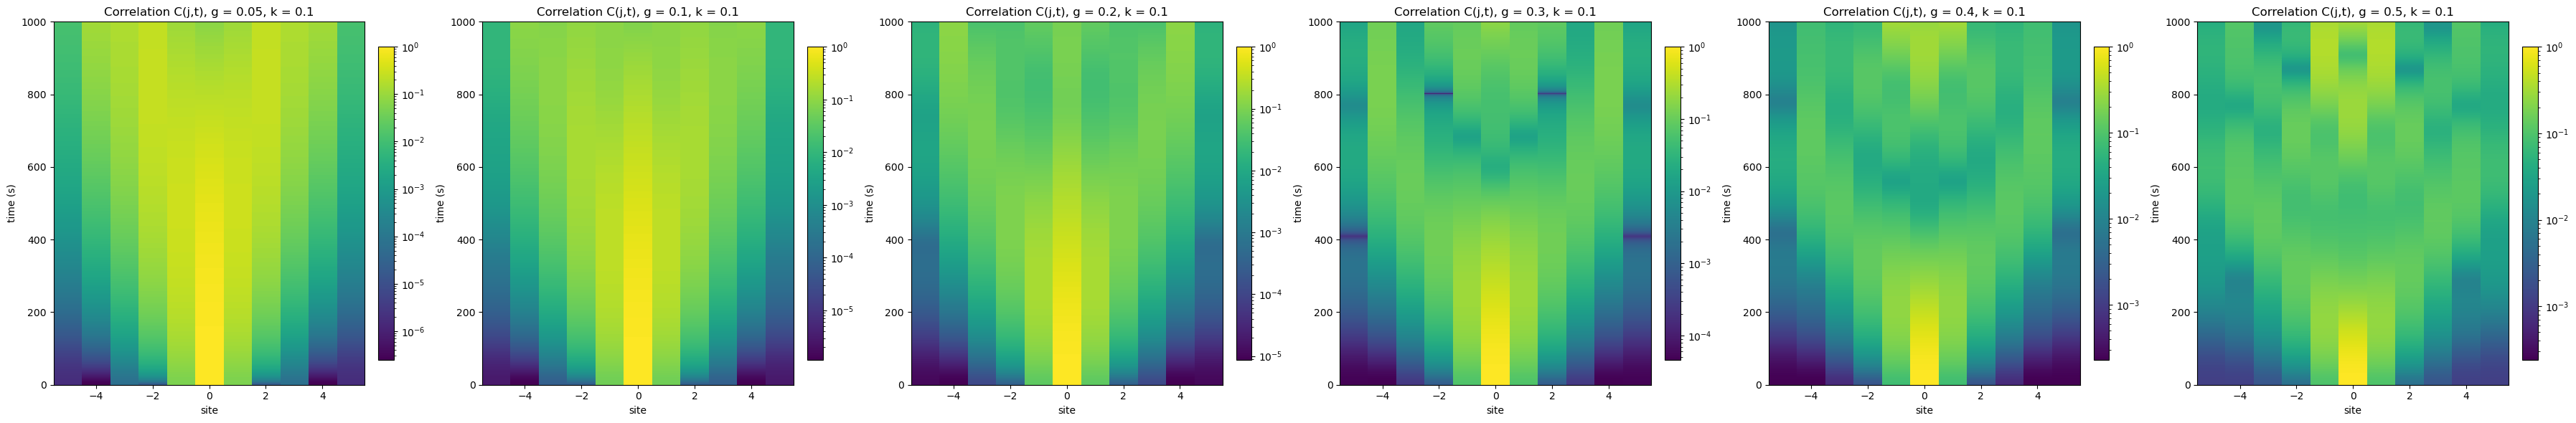

In [209]:
g_list = [0.05,0.1,0.2,0.3,0.4,0.5]
k_list = [0, 0.05, 0.1]
L = 11; J = 1.; X = sigmay; Y = sigmay; n = 12; dt = 0.01; h = 0; chi_max = 200
N = 2**n

for k in k_list:
    fig, ax = plt.subplots(nrows = 1, ncols = len(g_list), figsize = (6*len(g_list),6))
    for i, g in enumerate(g_list):
        simulation_ferro(L = L, J = J, g = g, X = X, Y = Y, n = n, dt = dt, k = k, h = h, chi_max = chi_max, log=True, ylim=[0,1000], ax=ax[i])
    plt.show()


### Paramagnetic

In [58]:
S_para, Corr_para = correlation_Ctj(L = L, J = J, g = 2, X = X, Y = Y, n = n, dt = dt, k = k, h = h, chi_max = chi_max)

finite TEBD, (imaginary time evolution)
L=11, J=1.0, g=2.00, h = 0, k = 0.100
dt = 0.10000: E = -24.1081504596669
dt = 0.01000: E = -24.1984851464065
dt = 0.00100: E = -24.2073282130231
dt = 0.00010: E = -24.2082081676558
dt = 0.00001: E = -24.2082962333497
final bond dimensions:  [2, 4, 8, 14, 14, 14, 14, 8, 4, 2]


Plot of Correlation Function

-6 5


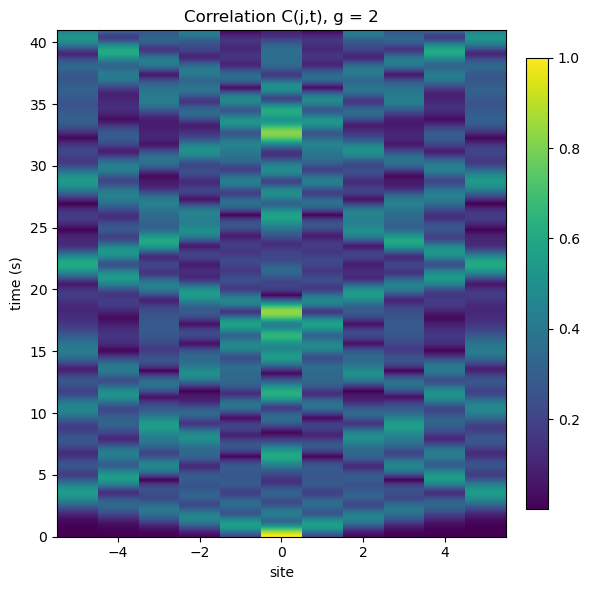

In [59]:
fig, ax = plt.subplots(figsize = (6,6))

im = ax.imshow(np.abs(Corr_para), aspect='auto', interpolation='none', origin = 'lower',  extent = [-(L//2)-0.5, L//2+0.5, 0, N*dt])
print(-L//2, L//2)
fig.colorbar(im, fraction=0.046, pad=0.04)  # Add colorbar
ax.set_title('Correlation C(j,t), g = 2')
ax.set(xlabel = 'site', ylabel = 'time (s)')

plt.tight_layout()